In [9]:
%pip install numpy pandas matplotlib seaborn 

1164.13s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 27.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 22.5 MB/s  0:00:00a 0:00:010:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 24.2 MB/s  0:00:00 25.8 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 23.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 25.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10/10 [seaborn]━  9/10 [seaborn]ib]

[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [14]:

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import matplotlib.ticker as ticker
import matplotlib.cm as cm
from warnings import filterwarnings
filterwarnings('ignore')

In [16]:
# SET PROFESSIONAL THEME
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("viridis")

viridis_colors = cm.viridis(np.linspace(0, 1, 5))
primary_color = viridis_colors[0]
secondary_color = viridis_colors[1]
accent_color = viridis_colors[2]
danger_color = "#800000"
neutral_color = viridis_colors[4]
custom_palette = viridis_colors


In [18]:
# LOAD DATASET

df = pd.read_csv("DataCoSupplyChainDataset.csv", encoding='latin-1')


# BASIC CHECK

print("Shape:", df.shape)
df.head()

Shape: (180519, 53)


,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 11:24,Standard Class


In [19]:
df.columns

Index(['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)',
       'Benefit per order', 'Sales per customer', 'Delivery Status',
       'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City',
       'Customer Country', 'Customer Email', 'Customer Fname', 'Customer Id',
       'Customer Lname', 'Customer Password', 'Customer Segment',
       'Customer State', 'Customer Street', 'Customer Zipcode',
       'Department Id', 'Department Name', 'Latitude', 'Longitude', 'Market',
       'Order City', 'Order Country', 'Order Customer Id',
       'order date (DateOrders)', 'Order Id', 'Order Item Cardprod Id',
       'Order Item Discount', 'Order Item Discount Rate', 'Order Item Id',
       'Order Item Product Price', 'Order Item Profit Ratio',
       'Order Item Quantity', 'Sales', 'Order Item Total',
       'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status',
       'Order Zipcode', 'Product Card Id', 'Product Category Id',
       'Product De

In [20]:
# Overview 
print('rows, cols:', df.shape)

print('\ncolumns:')
print(df.columns.tolist())

print('\nNum duplicates:', df.duplicated().sum())

print('\nMissing values (top 20):')
print(df.isna().sum().sort_values(ascending=False).head(20))

rows, cols: (180519, 53)

columns:
['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)', 'Benefit per order', 'Sales per customer', 'Delivery Status', 'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City', 'Customer Country', 'Customer Email', 'Customer Fname', 'Customer Id', 'Customer Lname', 'Customer Password', 'Customer Segment', 'Customer State', 'Customer Street', 'Customer Zipcode', 'Department Id', 'Department Name', 'Latitude', 'Longitude', 'Market', 'Order City', 'Order Country', 'Order Customer Id', 'order date (DateOrders)', 'Order Id', 'Order Item Cardprod Id', 'Order Item Discount', 'Order Item Discount Rate', 'Order Item Id', 'Order Item Product Price', 'Order Item Profit Ratio', 'Order Item Quantity', 'Sales', 'Order Item Total', 'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status', 'Order Zipcode', 'Product Card Id', 'Product Category Id', 'Product Description', 'Product Image', 'Product Name', 'Product Price', 'Produc

In [32]:
# Drop irrelevant / sensitive columns (not useful for analysis)
cols_to_drop = [
    'Customer Email', 'Customer Password',
    'Customer Fname', 'Customer Lname',
    'Product Description', 'Product Image',
    'Order Zipcode', 'Customer Zipcode'
]
df.drop(columns=cols_to_drop, inplace=True, errors='ignore')


# Remove cancelled orders (they don't contribute to delivery analysis)
df = df[df['Order Status'] != 'CANCELED']


# Convert date columns from object → datetime format
df['order date (DateOrders)'] = pd.to_datetime(df['order date (DateOrders)'])
df['shipping date (DateOrders)'] = pd.to_datetime(df['shipping date (DateOrders)'])


# Create feature: Order Processing Time (days between order and shipping)
df['order_processing_time'] = (
    df['shipping date (DateOrders)'] - df['order date (DateOrders)']
).dt.days


# Create feature: Delay
# Positive → late delivery, Negative → early delivery
df['delay'] = df['order_processing_time'] - df['Days for shipment (scheduled)']


# Create binary flag: 1 = late delivery, 0 = on-time/early
df['is_late'] = (df['delay'] > 0).astype(int)


# Extract time-based features (useful for trend analysis)
df['order_month'] = df['order date (DateOrders)'].dt.month
df['order_day'] = df['order date (DateOrders)'].dt.day_name()
df['order_hour'] = df['order date (DateOrders)'].dt.hour


# Check final dataset shape after cleaning
df.shape


# Preview cleaned data
df.head()

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Product Price,Product Status,shipping date (DateOrders),Shipping Mode,order_processing_time,delay,is_late,order_month,order_day,order_hour
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,327.75,0,2018-02-03 22:56:00,Standard Class,3,-1,0,1,Wednesday,22
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,327.75,0,2018-01-18 12:27:00,Standard Class,5,1,1,1,Saturday,12
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,327.75,0,2018-01-17 12:06:00,Standard Class,4,0,0,1,Saturday,12
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,327.75,0,2018-01-16 11:45:00,Standard Class,3,-1,0,1,Saturday,11
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,327.75,0,2018-01-15 11:24:00,Standard Class,2,-2,0,1,Saturday,11


In [42]:
categorical_cols = df.select_dtypes(include=['object', 'category']).columns

for col in categorical_cols:
    print(f"\nColumn: {col}")
    print("Unique values:", df[col].nunique())
    print(df[col].value_counts().head(5))


Column: Type
Unique values: 4
Type
DEBIT       69295
TRANSFER    46191
PAYMENT     41725
CASH        19616
Name: count, dtype: int64

Column: Delivery Status
Unique values: 4
Delivery Status
Late delivery        98977
Advance shipping     41592
Shipping on time     32196
Shipping canceled     4062
Name: count, dtype: int64

Column: Category Name
Unique values: 50
Category Name
Cleats                  24074
Men's Footwear          21779
Women's Apparel         20597
Indoor/Outdoor Games    18909
Fishing                 16989
Name: count, dtype: int64

Column: Customer City
Unique values: 563
Customer City
Caguas         65448
Chicago         3816
Los Angeles     3348
Brooklyn        3346
New York        1775
Name: count, dtype: int64

Column: Customer Country
Unique values: 2
Customer Country
EE. UU.        108838
Puerto Rico     67989
Name: count, dtype: int64

Column: Customer Segment
Unique values: 3
Customer Segment
Consumer       91635
Corporate      53660
Home Office    31532
Nam

In [43]:
# Basic statistics of delay
print(df['delay'].describe())


# Count of late vs on-time deliveries
delay_counts = df['is_late'].value_counts()

print("\nLate vs On-time:")
print(delay_counts)

count    176827.000000
mean          0.540183
std           1.492934
min          -2.000000
25%           0.000000
50%           1.000000
75%           1.000000
max           4.000000
Name: delay, dtype: float64

Late vs On-time:
is_late
1    96737
0    80090
Name: count, dtype: int64


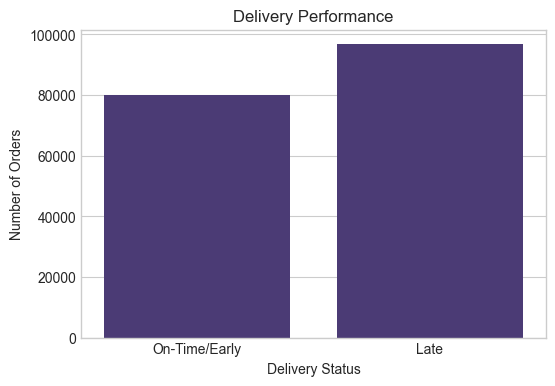

In [44]:
plt.figure(figsize=(6,4))
sns.countplot(x='is_late', data=df)

plt.xticks([0,1], ['On-Time/Early', 'Late'])
plt.title("Delivery Performance")
plt.xlabel("Delivery Status")
plt.ylabel("Number of Orders")

plt.show()

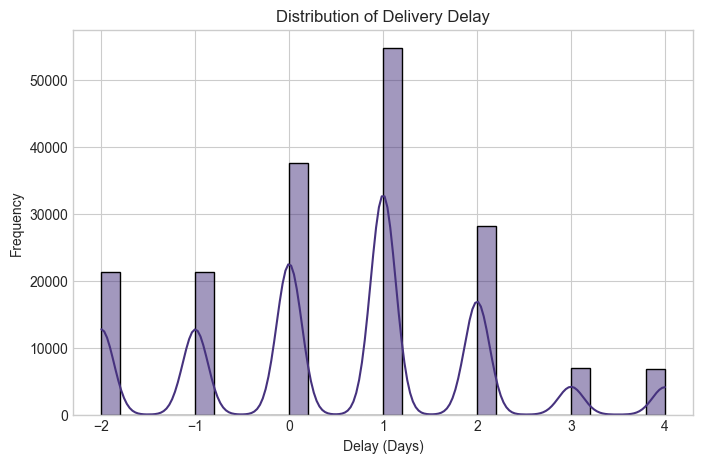

In [45]:
plt.figure(figsize=(8,5))
sns.histplot(df['delay'], bins=30, kde=True)

plt.title("Distribution of Delivery Delay")
plt.xlabel("Delay (Days)")
plt.ylabel("Frequency")

plt.show()

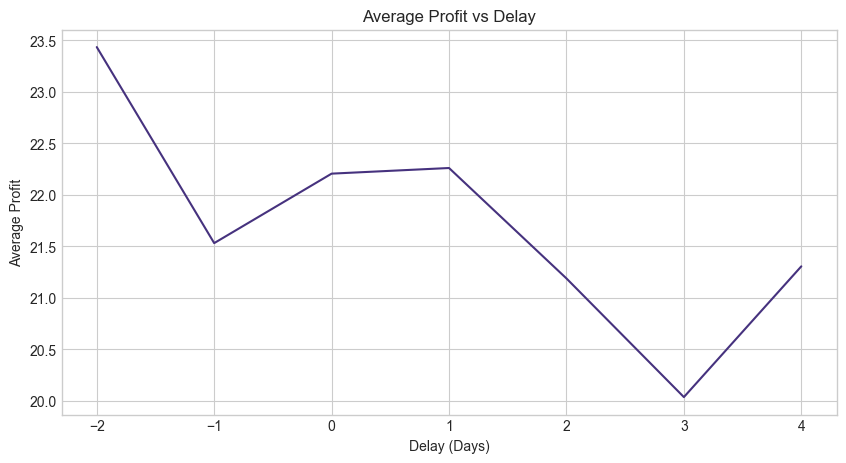

In [46]:
# Group by delay and calculate average profit
delay_profit = df.groupby('delay')['Order Profit Per Order'].mean().reset_index()

delay_profit = delay_profit.sort_values(by='delay')


plt.figure(figsize=(10,5))
plt.plot(delay_profit['delay'], delay_profit['Order Profit Per Order'])

plt.title("Average Profit vs Delay")
plt.xlabel("Delay (Days)")
plt.ylabel("Average Profit")

plt.show()

In [47]:
# Compare profit for late vs on-time
df.groupby('is_late')['Order Profit Per Order'].mean()

is_late
0    22.353284
1    21.721604
Name: Order Profit Per Order, dtype: float64

In [49]:
#Bottleneck Detection (Delay % by Category)

def delay_analysis(df, column):
    summary = df.groupby(column).agg(
        total_orders=('is_late', 'count'),
        late_orders=('is_late', 'sum')
    ).reset_index()
    
    summary['delay_pct'] = (summary['late_orders'] / summary['total_orders']) * 100
    
    return summary.sort_values(by='delay_pct', ascending=False)

In [50]:
# BY Region 

region_delay = delay_analysis(df, 'Order Region')
region_delay.head(10)

,Order Region,total_orders,late_orders,delay_pct
2,Central Africa,1644,971,59.063260
5,East Africa,1812,1014,55.960265
14,South of USA,3921,2194,55.955113
8,Eastern Europe,3859,2159,55.947137
13,South Asia,7599,4251,55.941571
15,Southeast Asia,9323,5208,55.861847
22,Western Europe,26572,14796,55.682673
20,West Asia,5893,3265,55.404717
18,US Center,5774,3192,55.282300
6,East of USA,6767,3729,55.105660


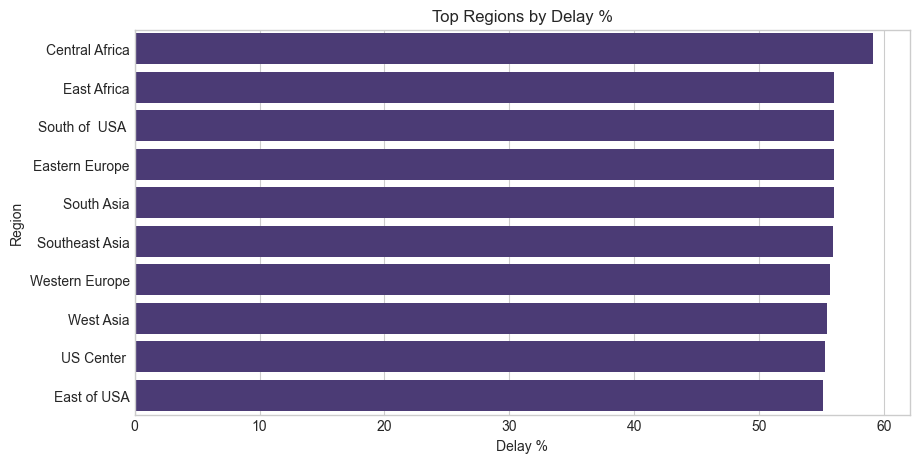

In [51]:
top_regions = region_delay.head(10)

plt.figure(figsize=(10,5))
sns.barplot(x='delay_pct', y='Order Region', data=top_regions)

plt.title("Top Regions by Delay %")
plt.xlabel("Delay %")
plt.ylabel("Region")

plt.show()

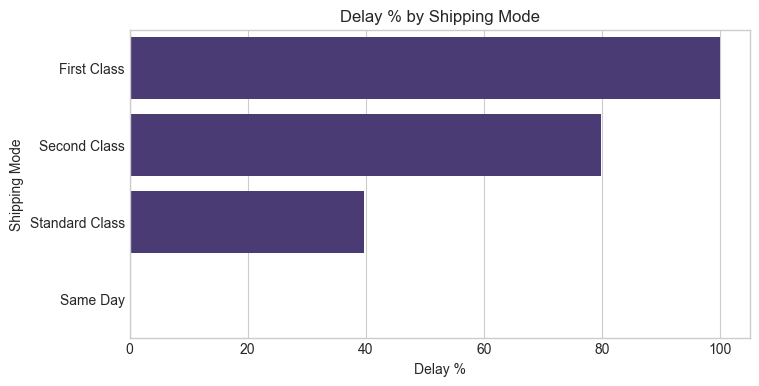

In [52]:
# Delay By shipping Mode 
shipping_delay = delay_analysis(df, 'Shipping Mode')
shipping_delay

plt.figure(figsize=(8,4))
sns.barplot(x='delay_pct', y='Shipping Mode', data=shipping_delay)

plt.title("Delay % by Shipping Mode")
plt.xlabel("Delay %")
plt.ylabel("Shipping Mode")

plt.show()

In [53]:
# Delay By Customer Support 

segment_delay = delay_analysis(df, 'Customer Segment')
segment_delay



,Customer Segment,total_orders,late_orders,delay_pct
2,Home Office,31532,17432,55.283522
0,Consumer,91635,50059,54.628690
1,Corporate,53660,29246,54.502423


In [54]:
# Delay By Department 

dept_delay = delay_analysis(df, 'Department Name')
dept_delay.head(10)

,Department Name,total_orders,late_orders,delay_pct
7,Health and Beauty,357,205,57.422969
9,Pet Shop,483,274,56.728778
10,Technology,1428,802,56.162465
8,Outdoors,9489,5269,55.527453
4,Fitness,2428,1347,55.477759
6,Golf,32512,17815,54.795153
5,Footwear,14219,7767,54.624095
0,Apparel,48011,26224,54.620816
3,Fan Shop,65516,35767,54.592771
2,Discs Shop,1982,1069,53.935419


In [55]:
# Root Cause Analysis 

# Finding top 5 worst region 

region_delay.head(5)

,Order Region,total_orders,late_orders,delay_pct
2,Central Africa,1644,971,59.063260
5,East Africa,1812,1014,55.960265
14,South of USA,3921,2194,55.955113
8,Eastern Europe,3859,2159,55.947137
13,South Asia,7599,4251,55.941571


In [56]:
# Filter Data for That Region

problem_region = 'Central Africa'   # change based on your output

df_region = df[df['Order Region'] == problem_region]

df_region.shape

(1644, 51)

In [59]:
# Analyse Drivers (Shipping, Status, Segment)

def root_cause(df, column):
    summary = df.groupby(column).agg(
        total_orders=('is_late', 'count'),
        late_orders=('is_late', 'sum'),
        avg_delay=('delay', 'mean')
    ).reset_index()
    
    summary['delay_pct'] = (summary['late_orders'] / summary['total_orders']) * 100
    
    return summary.sort_values(by='delay_pct', ascending=False)

In [61]:
#1  Shipping Mode (Major Cause) 

root_cause(df_region, 'Shipping Mode')

,Shipping Mode,total_orders,late_orders,avg_delay,delay_pct
0,First Class,289,289,1.000000,100.000000
2,Second Class,292,242,2.123288,82.876712
3,Standard Class,984,440,0.112805,44.715447
1,Same Day,79,0,0.000000,0.000000


In [62]:
#2. Order Status 

root_cause(df_region, 'Order Status')

,Order Status,total_orders,late_orders,avg_delay,delay_pct
7,SUSPECTED_FRAUD,28,23,1.035714,82.142857
3,PAYMENT_REVIEW,20,16,1.200000,80.000000
4,PENDING,188,130,0.574468,69.148936
5,PENDING_PAYMENT,326,204,0.736196,62.576687
6,PROCESSING,223,130,0.636771,58.295964
1,COMPLETE,587,324,0.574106,55.195911
0,CLOSED,200,107,0.465000,53.500000
2,ON_HOLD,72,37,0.652778,51.388889


In [63]:
#3. Customer Segment 
root_cause(df_region, 'Customer Segment')

,Customer Segment,total_orders,late_orders,avg_delay,delay_pct
0,Consumer,814,491,0.644963,60.319410
1,Corporate,532,313,0.500000,58.834586
2,Home Office,298,167,0.768456,56.040268


In [65]:
#4. DEpartment

root_cause(df_region, 'Department Name').head(10)

,Department Name,total_orders,late_orders,avg_delay,delay_pct
4,Golf,342,210,0.681287,61.403509
5,Outdoors,82,50,0.804878,60.975610
3,Footwear,132,79,0.553030,59.848485
1,Fan Shop,626,366,0.600639,58.466454
0,Apparel,439,254,0.612756,57.858770
2,Fitness,23,12,0.130435,52.173913


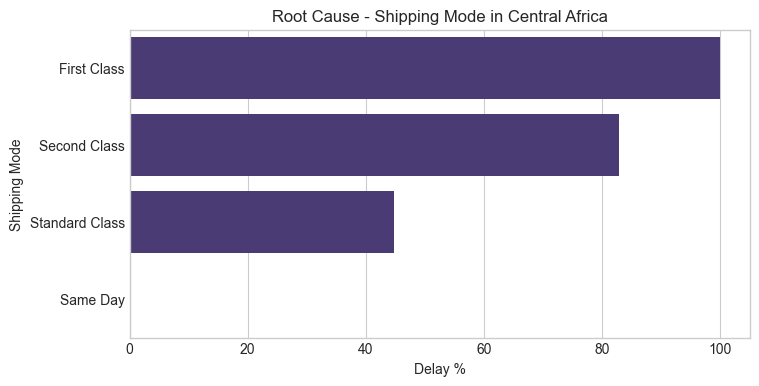

In [66]:
# Visualization (Top Root Cause)

top_shipping = root_cause(df_region, 'Shipping Mode')

plt.figure(figsize=(8,4))
sns.barplot(x='delay_pct', y='Shipping Mode', data=top_shipping)

plt.title(f"Root Cause - Shipping Mode in {problem_region}")
plt.xlabel("Delay %")
plt.ylabel("Shipping Mode")

plt.show()

In [67]:
# DDelay by Month

month_delay = df.groupby('order_month')['is_late'].mean() * 100

month_delay = month_delay.reset_index()

month_delay

,order_month,is_late
0,1,54.182230
1,2,54.646500
2,3,55.025608
3,4,54.558093
4,5,54.950559
5,6,54.596269
6,7,53.900937
7,8,55.389835
8,9,55.251352
9,10,54.024074


In [68]:
# Delay by Day of Week

day_delay = df.groupby('order_day')['is_late'].mean() * 100

day_delay = day_delay.reset_index()

# Arrange days properly
order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
day_delay['order_day'] = pd.Categorical(day_delay['order_day'], categories=order, ordered=True)
day_delay = day_delay.sort_values('order_day')

day_delay

,order_day,is_late
1,Monday,55.592092
5,Tuesday,54.030718
6,Wednesday,54.837680
4,Thursday,54.592707
0,Friday,54.533291
2,Saturday,54.290442
3,Sunday,55.072292


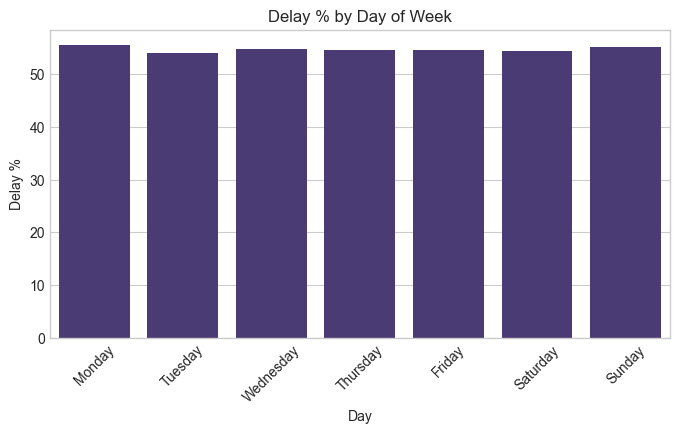

In [69]:
plt.figure(figsize=(8,4))
sns.barplot(x='order_day', y='is_late', data=day_delay)

plt.title("Delay % by Day of Week")
plt.xlabel("Day")
plt.ylabel("Delay %")

plt.xticks(rotation=45)
plt.show()

In [70]:
# DElay By HOur

hour_delay = df.groupby('order_hour')['is_late'].mean() * 100

hour_delay = hour_delay.reset_index()

hour_delay

,order_hour,is_late
0,0,54.108569
1,1,55.284772
2,2,55.300282
3,3,54.054795
4,4,53.829844
5,5,55.637683
6,6,52.430847
7,7,55.097614
8,8,53.053122
9,9,54.557823


In [71]:
month_delay['is_late'].std()

np.float64(0.5039808986458056)

In [73]:
# It is observed that timely analysis is not much helpful as difference in hourly, weekly and monthly and negligible

overall_delay = df['is_late'].mean() * 100

month_delay['difference_from_avg'] = month_delay['is_late'] - overall_delay

month_delay

,order_month,is_late,difference_from_avg
0,1,54.182230,-0.524913
1,2,54.646500,-0.060643
2,3,55.025608,0.318465
3,4,54.558093,-0.149050
4,5,54.950559,0.243415
5,6,54.596269,-0.110874
6,7,53.900937,-0.806206
7,8,55.389835,0.682692
8,9,55.251352,0.544209
9,10,54.024074,-0.683070


In [75]:
# PRedictive modelling for pedicting late delivery prediction


# Step 1: Select Features (Business + Time + Ops)
features = [
    'Days for shipment (scheduled)',
    'Shipping Mode',
    'Customer Segment',
    'Department Name',
    'Order Region',
    'order_month',
    'order_hour'
]

target = 'is_late'

df_model = df[features + [target]].copy()

In [86]:
# Step 2 : Handle Categorical Variables (Frequency Encoding)

for col in df_model.select_dtypes(include='object').columns:
    freq_map = df_model[col].value_counts(normalize=True)
    df_model[col] = df_model[col].map(freq_map)

In [87]:
# Step 3 : 3. Train-Test Split
from sklearn.model_selection import train_test_split

X = df_model.drop(columns=[target])
y = df_model[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [91]:
# Step 4 : Handle class imbalance 



from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

In [92]:
# step5 Train Multiple Models

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(max_depth=10),
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
}


In [94]:
# Step 6 Evaluate Models 

from sklearn.metrics import accuracy_score, precision_score, recall_score

results = []

for name, model in models.items():
    model.fit(X_train_sm, y_train_sm)
    y_pred = model.predict(X_test)
    
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred)
    })

results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall
0,Logistic Regression,0.668410,0.766338,0.566674
1,Decision Tree,0.723944,0.879364,0.574168
2,Random Forest,0.723689,0.886753,0.567397


In [96]:
#  Step 7 : BEst Model 

results_df.sort_values(by='Recall', ascending=False)

,Model,Accuracy,Precision,Recall
1,Decision Tree,0.723944,0.879364,0.574168
2,Random Forest,0.723689,0.886753,0.567397
0,Logistic Regression,0.668410,0.766338,0.566674


In [97]:
# Step 8: Now Decision Tree is best model for us , will train it

final_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)

final_model.fit(X_train_sm, y_train_sm)

y_pred = final_model.predict(X_test)

In [99]:
# Step 9 :  Detailed Evaluation 

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.64      0.91      0.75     16018
           1       0.89      0.57      0.69     19348

    accuracy                           0.72     35366
   macro avg       0.76      0.74      0.72     35366
weighted avg       0.77      0.72      0.72     35366



In [100]:
# Step 10 : Feature Importance 

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': final_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

importance

,Feature,Importance
0,Days for shipment (scheduled),0.495545
1,Shipping Mode,0.444886
4,Order Region,0.019381
3,Department Name,0.015417
6,order_hour,0.011087
5,order_month,0.007356
2,Customer Segment,0.006327


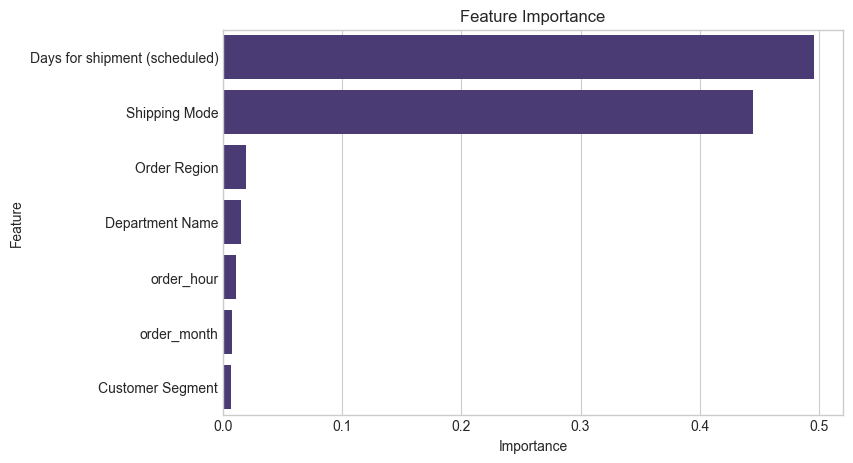

In [101]:
plt.figure(figsize=(8,5))
sns.barplot(x='Importance', y='Feature', data=importance)

plt.title("Feature Importance")
plt.show()

In [102]:
import pickle

# Save model
pickle.dump(final_model, open("model.pkl", "wb"))

# Save frequency encoding mappings
encoding_maps = {}

for col in df_model.select_dtypes(include='object').columns:
    encoding_maps[col] = df[col].value_counts(normalize=True).to_dict()

pickle.dump(encoding_maps, open("encoders.pkl", "wb"))

In [108]:
# Create app 

for col in df_model.select_dtypes(include='object').columns:
    encoding_maps[col] = df[col].value_counts(normalize=True).to_dict()

    import pickle

# Use ORIGINAL df (before encoding)
encoding_maps = {}

categorical_cols = [
    'Shipping Mode',
    'Customer Segment',
    'Department Name',
    'Order Region'
]

for col in categorical_cols:
    encoding_maps[col] = df[col].value_counts(normalize=True).to_dict()

# Save encoders
pickle.dump(encoding_maps, open("encoders.pkl", "wb"))

In [109]:
encoding_maps.keys()

dict_keys(['Shipping Mode', 'Customer Segment', 'Department Name', 'Order Region'])

In [1]:
%pip install plotly

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 19.2 MB/s  0:00:00 22.2 MB/s eta 0:00:01

[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
